In [1]:
#Creditwise Loan System

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (f1_score, accuracy_score, classification_report,
                              confusion_matrix, precision_score, recall_score)
from sklearn.pipeline import Pipeline


In [3]:
df = pd.read_csv("loan_approval_data.csv")
print("Shape:", df.shape)
df.head()

print(df.info())
print("\n")
print(df.describe())

Shape: (1000, 20)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_ID        950 non-null    float64
 1   Applicant_Income    950 non-null    float64
 2   Coapplicant_Income  950 non-null    float64
 3   Employment_Status   950 non-null    object 
 4   Age                 950 non-null    float64
 5   Marital_Status      950 non-null    object 
 6   Dependents          950 non-null    float64
 7   Credit_Score        950 non-null    float64
 8   Existing_Loans      950 non-null    float64
 9   DTI_Ratio           950 non-null    float64
 10  Savings             950 non-null    float64
 11  Collateral_Value    950 non-null    float64
 12  Loan_Amount         950 non-null    float64
 13  Loan_Term           950 non-null    float64
 14  Loan_Purpose        950 non-null    object 
 15  Property_Area       950 non-null    ob

In [4]:
print("Missing values per column:")
print(df.isnull().sum())
print("Total missing:",df.isnull().sum().sum())

Missing values per column:
Applicant_ID          50
Applicant_Income      50
Coapplicant_Income    50
Employment_Status     50
Age                   50
Marital_Status        50
Dependents            50
Credit_Score          50
Existing_Loans        50
DTI_Ratio             50
Savings               50
Collateral_Value      50
Loan_Amount           50
Loan_Term             50
Loan_Purpose          50
Property_Area         50
Education_Level       50
Gender                50
Employer_Category     50
Loan_Approved         50
dtype: int64
Total missing: 1000


Loan Approval Distribution:
Loan_Approved
No     652
Yes    298
Name: count, dtype: int64

Percentage:
Loan_Approved
No     68.631579
Yes    31.368421
Name: proportion, dtype: float64


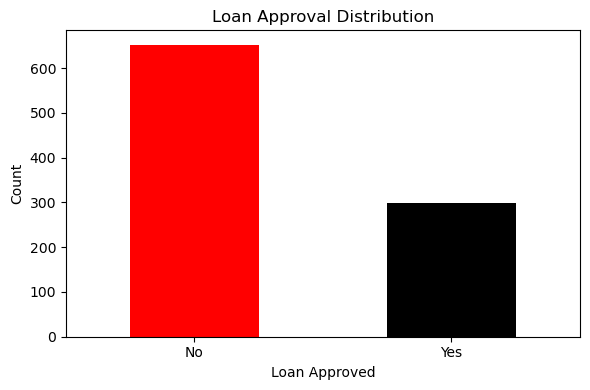

In [5]:
#checking target (loan approval) distribution

print("Loan Approval Distribution:")
print(df['Loan_Approved'].value_counts())
print("\nPercentage:")
print(df['Loan_Approved'].value_counts(normalize=True) * 100)

plt.figure(figsize=(6, 4))
df['Loan_Approved'].value_counts().plot(kind='bar', color=['red', 'black'])
plt.title("Loan Approval Distribution")
plt.xlabel("Loan Approved")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

<Figure size 1000x400 with 0 Axes>

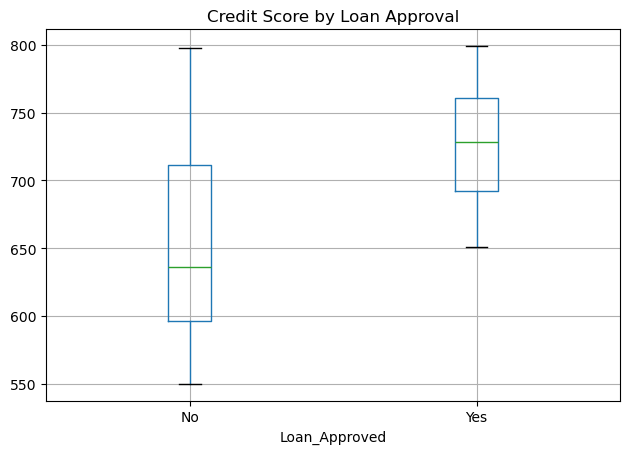

<Figure size 1000x400 with 0 Axes>

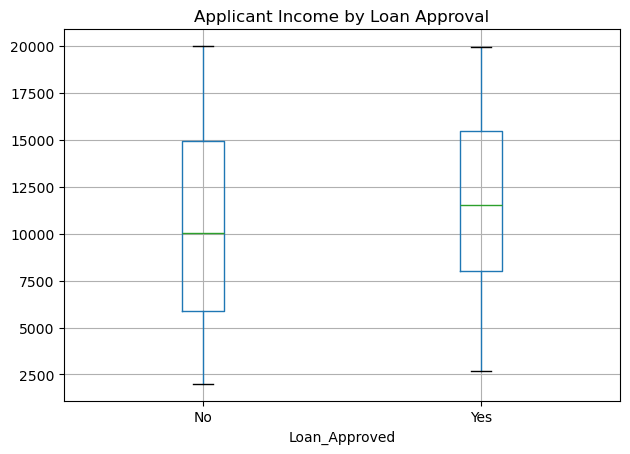

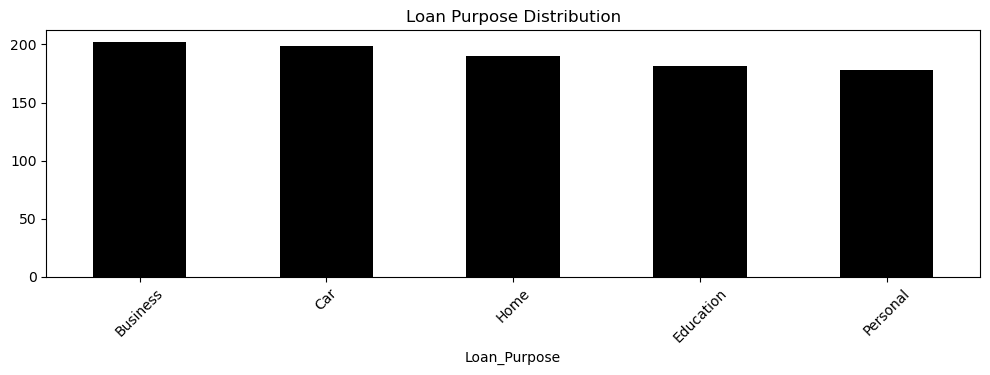

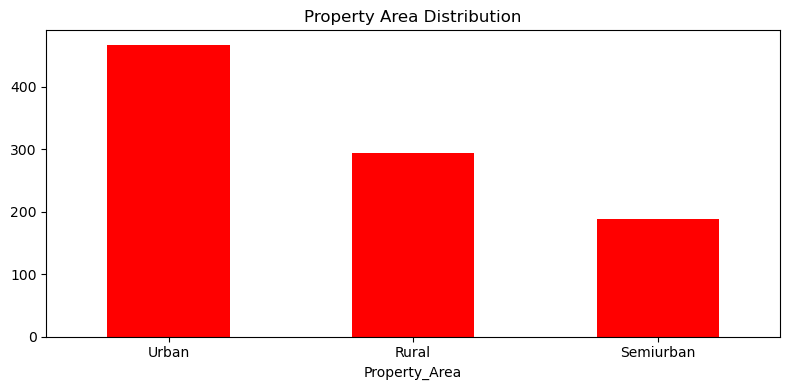

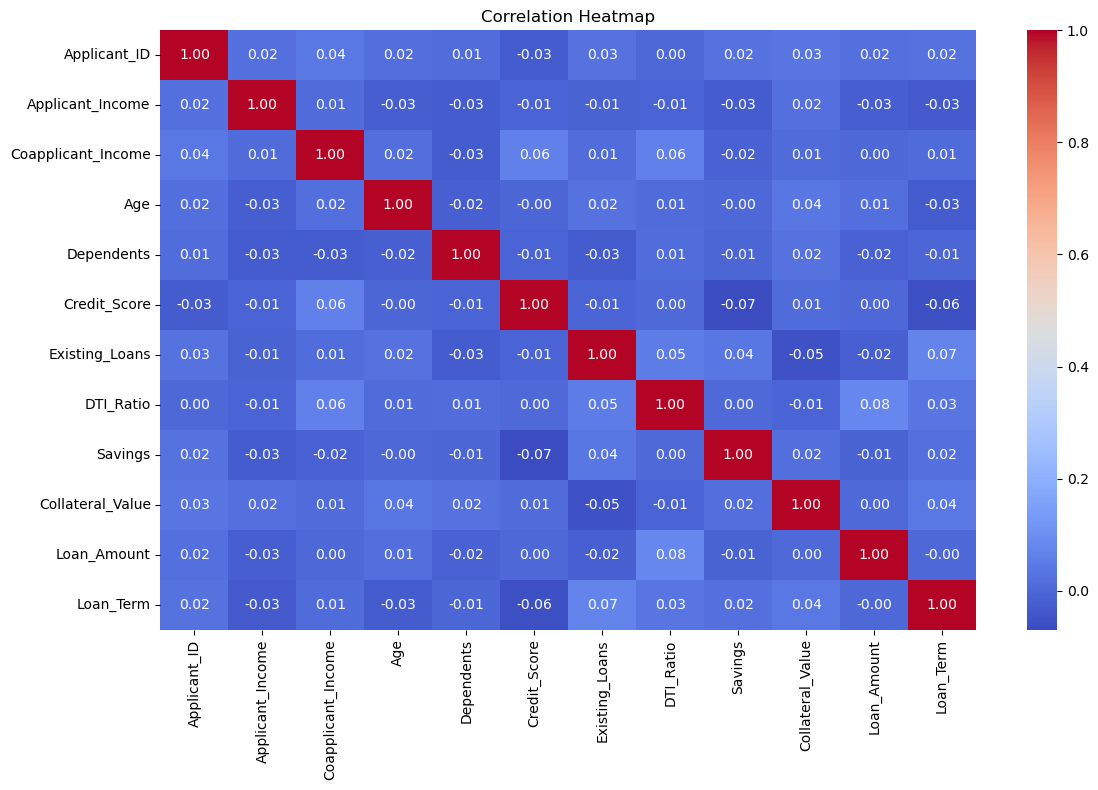

In [6]:
#EDA (Exploratory Data Analysis)

# Credit Score distribution by approval
plt.figure(figsize=(10, 4))
df.boxplot(column='Credit_Score', by='Loan_Approved')
plt.title("Credit Score by Loan Approval")
plt.suptitle("")
plt.tight_layout()
plt.show()


# Income distribution by approval
plt.figure(figsize=(10, 4))
df.boxplot(column='Applicant_Income', by='Loan_Approved')
plt.title("Applicant Income by Loan Approval")
plt.suptitle("")
plt.tight_layout()
plt.show()


# Loan Purpose distribution
plt.figure(figsize=(10, 4))
df['Loan_Purpose'].value_counts().plot(kind='bar', color='black')
plt.title("Loan Purpose Distribution")
plt.suptitle("")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Property Area distribytion
plt.figure(figsize=(8, 4))
df['Property_Area'].value_counts().plot(kind='bar', color='red')
plt.title("Property Area Distribution")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


# Correlation hetmap for numeric features
plt.figure(figsize=(12, 8))
numerical_cols = df.select_dtypes(include=[np.number]).columns
sns.heatmap(df[numerical_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()


In [7]:
#dropping useless columns 
df = df.drop('Applicant_ID', axis=1)
print("Shape after dropping ID:", df.shape)

Shape after dropping ID: (1000, 19)


In [8]:
# Separating numerical and categorical columns

numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

print("Numerical columns:", numerical_cols)
print("Categorical columns:", categorical_cols)

Numerical columns: ['Applicant_Income', 'Coapplicant_Income', 'Age', 'Dependents', 'Credit_Score', 'Existing_Loans', 'DTI_Ratio', 'Savings', 'Collateral_Value', 'Loan_Amount', 'Loan_Term']
Categorical columns: ['Employment_Status', 'Marital_Status', 'Loan_Purpose', 'Property_Area', 'Education_Level', 'Gender', 'Employer_Category', 'Loan_Approved']


In [9]:
#this data has clearly many outliers
#therefore filling missing values with mdeian 
# median is better than mean when data has outliers

for col in numerical_cols:
    median_val = df[col].median()
    df[col] = df[col].fillna(median_val)

#verifying again if there is still missing values or not 
print("\n Missing values after handling:")
print(df.isnull().sum())


 Missing values after handling:
Applicant_Income       0
Coapplicant_Income     0
Employment_Status     50
Age                    0
Marital_Status        50
Dependents             0
Credit_Score           0
Existing_Loans         0
DTI_Ratio              0
Savings                0
Collateral_Value       0
Loan_Amount            0
Loan_Term              0
Loan_Purpose          50
Property_Area         50
Education_Level       50
Gender                50
Employer_Category     50
Loan_Approved         50
dtype: int64


In [10]:
#now the missing values of numerical types are handled 
#now handaling the missing values of categorical columns using LabelEncoder

#first  handaling target variable
# STEP 1 — Fill missing values FIRST
df['Loan_Approved'] = df['Loan_Approved'].fillna(df['Loan_Approved'].mode()[0])

# STEP 2 — THEN encode Yes/No to 1/0
df['Loan_Approved'] = df['Loan_Approved'].map({'Yes': 1, 'No': 0})

# STEP 3 — Verify no NaN left
print(df['Loan_Approved'].isnull().sum())  # should print 0
print(df['Loan_Approved'].value_counts())

le = LabelEncoder()
categorical_features = ['Employment_Status', 'Marital_Status', 'Loan_Purpose',
                         'Property_Area', 'Education_Level', 'Gender', 
                         'Employer_Category']

for col in categorical_features:
    df[col] = le.fit_transform(df[col])
    print(f"{col} encoded successfully")

print("\nData types after encoding:")
print(df.info())
print("\nFirst 3 rows:")
print(df.head(3))


0
Loan_Approved
0    702
1    298
Name: count, dtype: int64
Employment_Status encoded successfully
Marital_Status encoded successfully
Loan_Purpose encoded successfully
Property_Area encoded successfully
Education_Level encoded successfully
Gender encoded successfully
Employer_Category encoded successfully

Data types after encoding:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_Income    1000 non-null   float64
 1   Coapplicant_Income  1000 non-null   float64
 2   Employment_Status   1000 non-null   int64  
 3   Age                 1000 non-null   float64
 4   Marital_Status      1000 non-null   int64  
 5   Dependents          1000 non-null   float64
 6   Credit_Score        1000 non-null   float64
 7   Existing_Loans      1000 non-null   float64
 8   DTI_Ratio           1000 non-null   float64
 9   Savings       

In [11]:
#splitting x and y
X=df.drop('Loan_Approved',axis=1)
Y=df['Loan_Approved']

print("Features shape:",X.shape)
print("Target shape:",Y.shape)
print("\nClass distribution:")
print(X.value_counts())

Features shape: (1000, 18)
Target shape: (1000,)

Class distribution:
Applicant_Income  Coapplicant_Income  Employment_Status  Age   Marital_Status  Dependents  Credit_Score  Existing_Loans  DTI_Ratio  Savings  Collateral_Value  Loan_Amount  Loan_Term  Loan_Purpose  Property_Area  Education_Level  Gender  Employer_Category
2009.0            9435.0              3                  30.0  0               3.0         666.0         4.0             0.15       6999.0   24321.0           13877.0      84.0       5             2              1                1       3                    1
13314.0           4612.0              0                  23.0  0               3.0         607.0         1.0             0.36       3751.0   14497.0           21210.5      84.0       1             1              0                1       1                    1
13130.0           5205.5              1                  38.0  1               1.0         647.0         4.0             0.55       8625.0   14298.0       

In [12]:
# Usiing stratify=y because dataset is imbalanced (65/35)
# This ensures both train and test have same class ratio

X_train, X_test, y_train, y_test = train_test_split(
    X, Y,
    test_size=0.2,
    random_state=42,
    stratify=Y
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)
print("\nTrain class distribution:")
print(y_train.value_counts(normalize=True) * 100)
print("\nTest class distribution:")
print(y_test.value_counts(normalize=True) * 100)


Training set: (800, 18)
Test set: (200, 18)

Train class distribution:
Loan_Approved
0    70.25
1    29.75
Name: proportion, dtype: float64

Test class distribution:
Loan_Approved
0    70.0
1    30.0
Name: proportion, dtype: float64


In [13]:
# Decision Trees don't need scaling
# But Logistic Regression does so 
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

BASELINE DECISION TREE
Accuracy:  0.9000
F1 Score:  0.8438
Precision: 0.7941
Recall:    0.9000

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.90      0.93       140
           1       0.79      0.90      0.84        60

    accuracy                           0.90       200
   macro avg       0.87      0.90      0.89       200
weighted avg       0.91      0.90      0.90       200



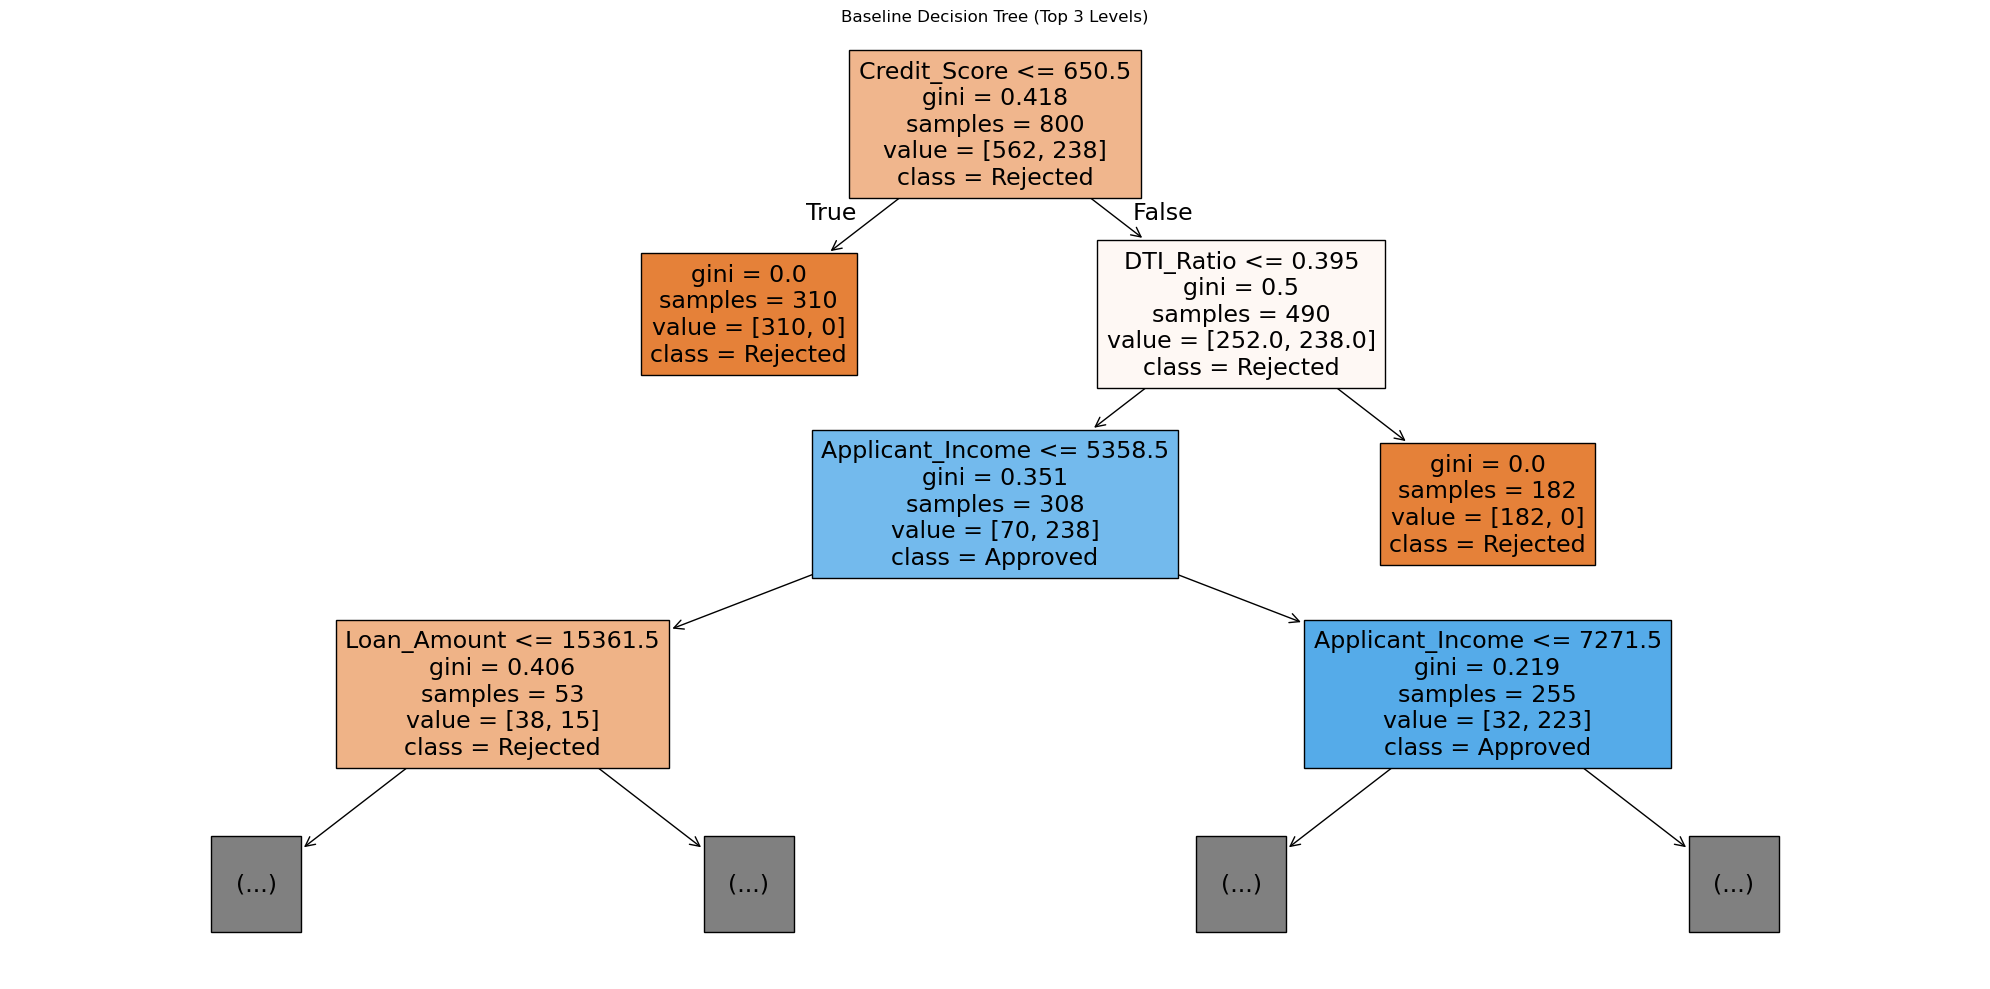

In [14]:
#baseline decision Tree

baseline_dt = DecisionTreeClassifier(random_state=42)
baseline_dt.fit(X_train, y_train)
y_pred_baseline = baseline_dt.predict(X_test)

print("=" * 50)
print("BASELINE DECISION TREE")
print("=" * 50)
print(f"Accuracy:  {accuracy_score(y_test, y_pred_baseline):.4f}")
print(f"F1 Score:  {f1_score(y_test, y_pred_baseline):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_baseline):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_baseline):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_baseline))

plt.figure(figsize=(20, 10))
plot_tree(
    baseline_dt,
    feature_names=X.columns,
    class_names=["Rejected", "Approved"],
    filled=True,
    max_depth=3
)
plt.title("Baseline Decision Tree (Top 3 Levels)")
plt.tight_layout()
plt.show()


Finding best max_depth...
max_depth= 2 → F1: 0.8333
max_depth= 3 → F1: 0.8397
max_depth= 4 → F1: 0.8593
max_depth= 5 → F1: 0.8722
max_depth= 6 → F1: 0.8636
max_depth= 7 → F1: 0.8636
max_depth= 8 → F1: 0.8550
max_depth=10 → F1: 0.8615
max_depth=12 → F1: 0.8413

Best max_depth: 5 with F1: 0.8722


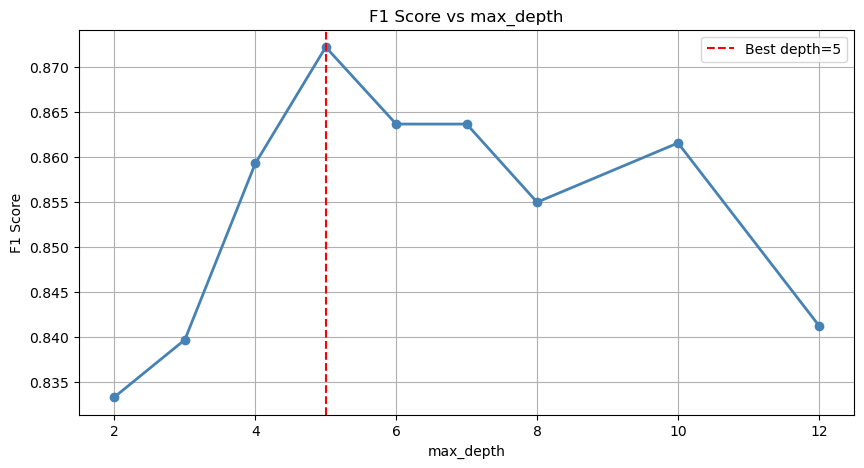

Finding best min_samples_leaf...
min_samples_leaf=  5 → F1: 0.8722
min_samples_leaf= 10 → F1: 0.8657
min_samples_leaf= 20 → F1: 0.8593
min_samples_leaf= 30 → F1: 0.8397
min_samples_leaf= 50 → F1: 0.8397
min_samples_leaf= 75 → F1: 0.7627
min_samples_leaf=100 → F1: 0.8333

Best min_samples_leaf: 5 with F1: 0.8722


In [15]:
#Doing prepruning:finding best mx_depth and best min_samples_leaf
depths = [2, 3, 4, 5, 6, 7, 8, 10, 12]
f1_scores_depth = []

print("Finding best max_depth...")
for depth in depths:
    model = DecisionTreeClassifier(max_depth=depth, random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    score = f1_score(y_test, y_pred)
    f1_scores_depth.append(score)
    print(f"max_depth={depth:2d} → F1: {score:.4f}")

best_depth = depths[f1_scores_depth.index(max(f1_scores_depth))]
print(f"\nBest max_depth: {best_depth} with F1: {max(f1_scores_depth):.4f}")

# Plot
plt.figure(figsize=(10, 5))
plt.plot(depths, f1_scores_depth, marker='o', color='steelblue', linewidth=2)
plt.axvline(x=best_depth, color='red', linestyle='--', label=f'Best depth={best_depth}')
plt.xlabel("max_depth")
plt.ylabel("F1 Score")
plt.title("F1 Score vs max_depth")
plt.legend()
plt.grid(True)
plt.show()

min_samples = [5, 10, 20, 30, 50, 75, 100]
f1_scores_leaf = []

print("Finding best min_samples_leaf...")
for samples in min_samples:
    model = DecisionTreeClassifier(
        max_depth=best_depth,
        min_samples_leaf=samples,
        random_state=42
    )
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    score = f1_score(y_test, y_pred)
    f1_scores_leaf.append(score)
    print(f"min_samples_leaf={samples:3d} → F1: {score:.4f}")

best_leaf = min_samples[f1_scores_leaf.index(max(f1_scores_leaf))]
print(f"\nBest min_samples_leaf: {best_leaf} with F1: {max(f1_scores_leaf):.4f}")


In [16]:
#prepruned model
pre_pruned_dt = DecisionTreeClassifier(
    max_depth=best_depth,
    min_samples_leaf=best_leaf,
    class_weight='balanced',
    random_state=42
)
pre_pruned_dt.fit(X_train, y_train)
y_pred_pre = pre_pruned_dt.predict(X_test)

print("=" * 50)
print("PRE-PRUNED DECISION TREE")
print("=" * 50)
print(f"Accuracy:  {accuracy_score(y_test, y_pred_pre):.4f}")
print(f"F1 Score:  {f1_score(y_test, y_pred_pre):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_pre):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_pre):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_pre))


PRE-PRUNED DECISION TREE
Accuracy:  0.9000
F1 Score:  0.8507
Precision: 0.7703
Recall:    0.9500

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.88      0.92       140
           1       0.77      0.95      0.85        60

    accuracy                           0.90       200
   macro avg       0.87      0.91      0.89       200
weighted avg       0.91      0.90      0.90       200



Number of alpha values to try: 17
Best ccp_alpha: 0.003043
Best F1: 0.8722


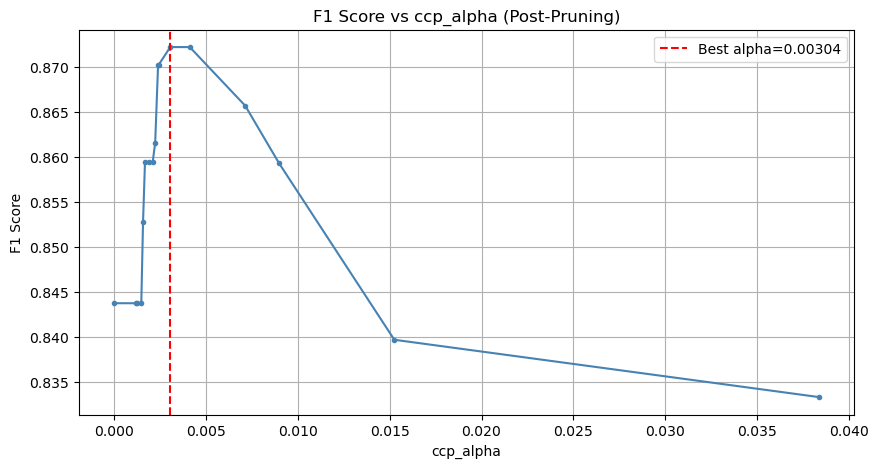

POST-PRUNED DECISION TREE
Accuracy:  0.9000
F1 Score:  0.8507
Precision: 0.7703
Recall:    0.9500
              precision    recall  f1-score   support

           0       0.98      0.88      0.92       140
           1       0.77      0.95      0.85        60

    accuracy                           0.90       200
   macro avg       0.87      0.91      0.89       200
weighted avg       0.91      0.90      0.90       200



In [17]:
#Post-Pruning (ccp_alpha)

#1: Growing full tree
full_tree = DecisionTreeClassifier(random_state=42)
full_tree.fit(X_train, y_train)

#2: Gettig all alpha values
path = full_tree.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas[:-1]
print(f"Number of alpha values to try: {len(ccp_alphas)}")

#4: Trying all alphas
f1_scores_alpha = []
for alpha in ccp_alphas:
    model = DecisionTreeClassifier(ccp_alpha=alpha, random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    f1_scores_alpha.append(f1_score(y_test, y_pred))

#4: Finding best alpha
best_alpha = ccp_alphas[f1_scores_alpha.index(max(f1_scores_alpha))]
print(f"Best ccp_alpha: {best_alpha:.6f}")
print(f"Best F1: {max(f1_scores_alpha):.4f}")

# Plot
plt.figure(figsize=(10, 5))
plt.plot(ccp_alphas[:50], f1_scores_alpha[:50], marker='o',
         markersize=3, color='steelblue')
plt.axvline(x=best_alpha, color='red', linestyle='--',
            label=f'Best alpha={best_alpha:.5f}')
plt.xlabel("ccp_alpha")
plt.ylabel("F1 Score")
plt.title("F1 Score vs ccp_alpha (Post-Pruning)")
plt.legend()
plt.grid(True)
plt.show()

#5: Final post-pruned model
post_pruned_dt = DecisionTreeClassifier(
    ccp_alpha=best_alpha,
    class_weight='balanced',
    random_state=42
)
post_pruned_dt.fit(X_train, y_train)
y_pred_post = post_pruned_dt.predict(X_test)

print("=" * 50)
print("POST-PRUNED DECISION TREE")
print("=" * 50)
print(f"Accuracy:  {accuracy_score(y_test, y_pred_post):.4f}")
print(f"F1 Score:  {f1_score(y_test, y_pred_post):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_post):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_post):.4f}")
print(classification_report(y_test, y_pred_post))

In [18]:
#GridsearchCV

params = {
    'max_depth': [3, 4, 5, 6, 7, 8],
    'min_samples_leaf': [5, 10, 20, 30, 50],
    'class_weight': ['balanced', None],
    'criterion': ['gini', 'entropy']
}

grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    params,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)
grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best CV F1 Score:", round(grid.best_score_, 4))

best_dt = grid.best_estimator_
y_pred_best_dt = best_dt.predict(X_test)

print("=" * 50)
print("BEST DECISION TREE (GridSearchCV)")
print("=" * 50)
print(f"Accuracy:  {accuracy_score(y_test, y_pred_best_dt):.4f}")
print(f"F1 Score:  {f1_score(y_test, y_pred_best_dt):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_best_dt):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_best_dt):.4f}")
print(classification_report(y_test, y_pred_best_dt))

Fitting 5 folds for each of 120 candidates, totalling 600 fits
Best Parameters: {'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': 6, 'min_samples_leaf': 10}
Best CV F1 Score: 0.9284
BEST DECISION TREE (GridSearchCV)
Accuracy:  0.9000
F1 Score:  0.8507
Precision: 0.7703
Recall:    0.9500
              precision    recall  f1-score   support

           0       0.98      0.88      0.92       140
           1       0.77      0.95      0.85        60

    accuracy                           0.90       200
   macro avg       0.87      0.91      0.89       200
weighted avg       0.91      0.90      0.90       200



In [19]:
#LOGISTIC REGRESSION BSELINE

lr_baseline = LogisticRegression(max_iter=1000, random_state=42)
lr_baseline.fit(X_train_scaled, y_train)
y_pred_lr = lr_baseline.predict(X_test_scaled)

print("=" * 50)
print("LOGISTIC REGRESSION (Baseline)")
print("=" * 50)
print(f"Accuracy:  {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"F1 Score:  {f1_score(y_test, y_pred_lr):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_lr):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_lr):.4f}")
print(classification_report(y_test, y_pred_lr))


LOGISTIC REGRESSION (Baseline)
Accuracy:  0.8000
F1 Score:  0.6825
Precision: 0.6515
Recall:    0.7167
              precision    recall  f1-score   support

           0       0.87      0.84      0.85       140
           1       0.65      0.72      0.68        60

    accuracy                           0.80       200
   macro avg       0.76      0.78      0.77       200
weighted avg       0.81      0.80      0.80       200



In [20]:
#Logistic Regression with Regularization

# L2 Ridge
lr_l2 = LogisticRegression(
    penalty='l2', C=1.0,
    max_iter=1000, random_state=42,
    class_weight='balanced'
)
lr_l2.fit(X_train_scaled, y_train)
y_pred_lr_l2 = lr_l2.predict(X_test_scaled)

# L1 Lasso
lr_l1 = LogisticRegression(
    penalty='l1', C=1.0,
    solver='liblinear',
    max_iter=1000, random_state=42,
    class_weight='balanced'
)
lr_l1.fit(X_train_scaled, y_train)
y_pred_lr_l1 = lr_l1.predict(X_test_scaled)

# Using Python's built-in round(number, decimals) function
print("L2 Ridge F1:", round(f1_score(y_test, y_pred_lr_l2), 4))
print("L1 Lasso F1:", round(f1_score(y_test, y_pred_lr_l1), 4))

L2 Ridge F1: 0.7034
L1 Lasso F1: 0.7034


In [26]:
#KNN
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)
y_pred_knn = knn.predict(X_test_scaled)

print("=" * 50)
print("KNN MODEL (k=5)")
print("=" * 50)
print(f"Accuracy:  {accuracy_score(y_test, y_pred_knn):.4f}")
print(f"F1 Score:  {f1_score(y_test, y_pred_knn):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_knn):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_knn):.4f}")
print(classification_report(y_test, y_pred_knn))

#NAIVE BAYES
from sklearn.naive_bayes import GaussianNB

nb = GaussianNB()
nb.fit(X_train_scaled, y_train)
y_pred_nb = nb.predict(X_test_scaled)

print("=" * 50)
print("NAIVE BAYES MODEL")
print("=" * 50)
print(f"Accuracy:  {accuracy_score(y_test, y_pred_nb):.4f}")
print(f"F1 Score:  {f1_score(y_test, y_pred_nb):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_nb):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_nb):.4f}")
print(classification_report(y_test, y_pred_nb))

KNN MODEL (k=5)
Accuracy:  0.7350
F1 Score:  0.5546
Precision: 0.5593
Recall:    0.5500
              precision    recall  f1-score   support

           0       0.81      0.81      0.81       140
           1       0.56      0.55      0.55        60

    accuracy                           0.73       200
   macro avg       0.68      0.68      0.68       200
weighted avg       0.73      0.73      0.73       200

NAIVE BAYES MODEL
Accuracy:  0.8200
F1 Score:  0.7000
Precision: 0.7000
Recall:    0.7000
              precision    recall  f1-score   support

           0       0.87      0.87      0.87       140
           1       0.70      0.70      0.70        60

    accuracy                           0.82       200
   macro avg       0.79      0.79      0.79       200
weighted avg       0.82      0.82      0.82       200



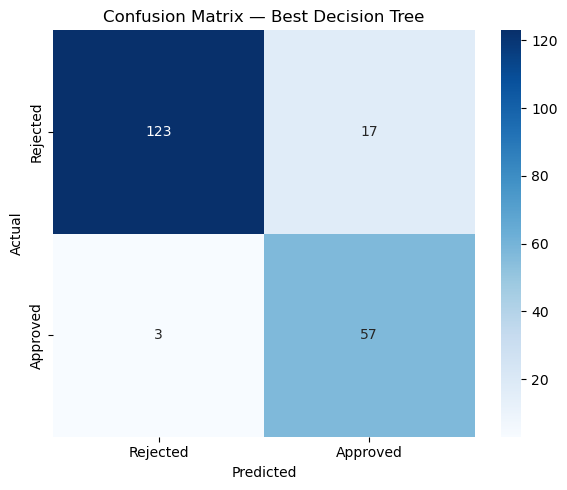

In [21]:
#Confusion Matrix for Best Model

cm = confusion_matrix(y_test, y_pred_best_dt)
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=["Rejected", "Approved"],
    yticklabels=["Rejected", "Approved"]
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix — Best Decision Tree")
plt.tight_layout()
plt.show()


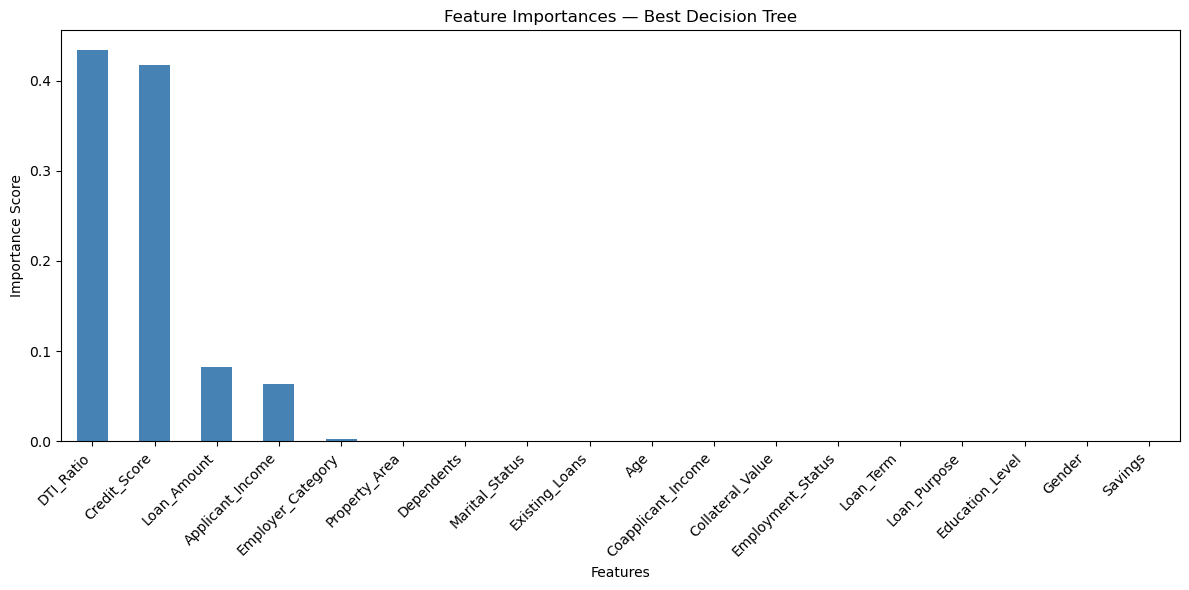

Top 5 Most Important Features:
DTI_Ratio            0.434147
Credit_Score         0.417678
Loan_Amount          0.082867
Applicant_Income     0.063010
Employer_Category    0.002297
dtype: float64


In [22]:
#Feature Importance

importances = pd.Series(
    best_dt.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(12, 6))
importances.plot(kind='bar', color='steelblue')
plt.title("Feature Importances — Best Decision Tree")
plt.xlabel("Features")
plt.ylabel("Importance Score")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("Top 5 Most Important Features:")
print(importances.head())


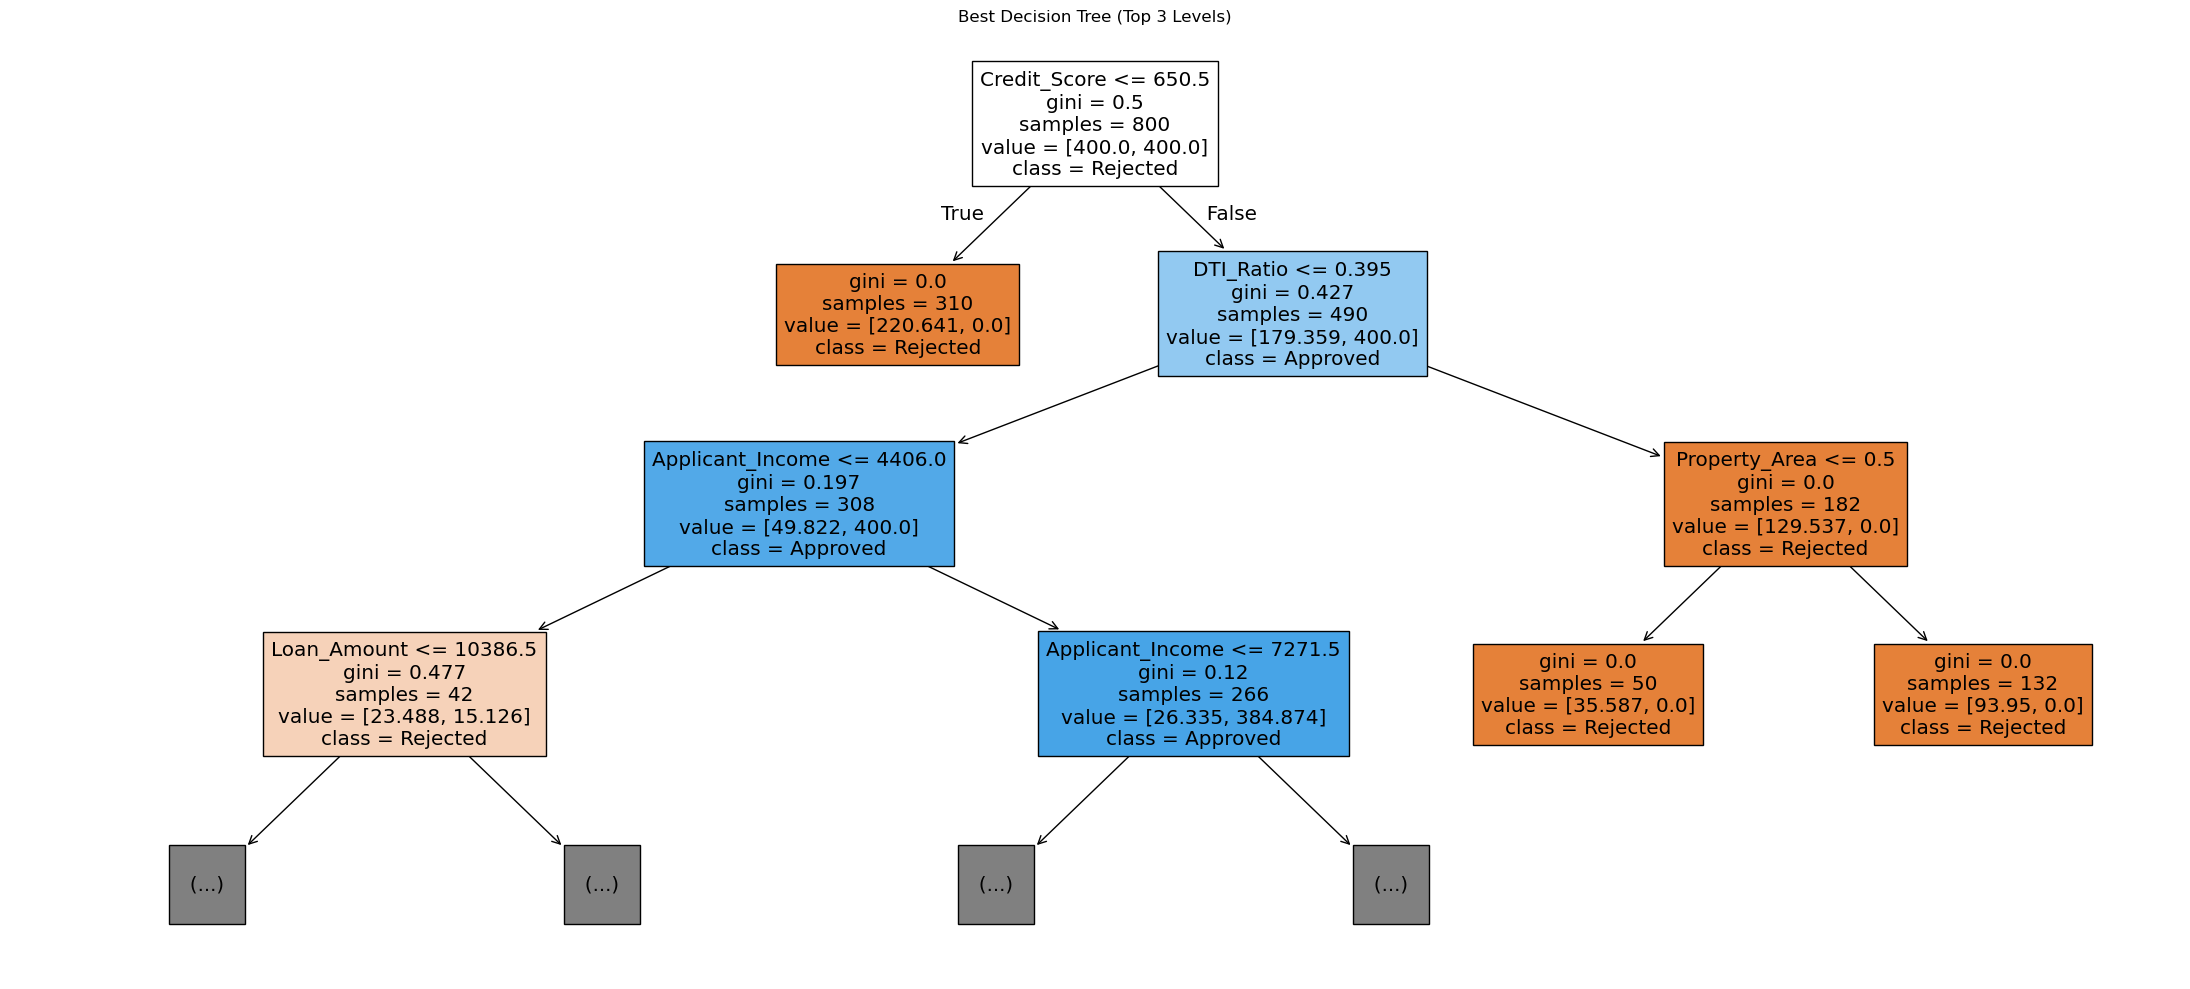

In [23]:
#Visualize Best Tree

plt.figure(figsize=(22, 10))
plot_tree(
    best_dt,
    feature_names=X.columns,
    class_names=["Rejected", "Approved"],
    filled=True,
    max_depth=3
)
plt.title("Best Decision Tree (Top 3 Levels)")
plt.tight_layout()
plt.show()

In [24]:
#Cross Validation Score

cv_scores = cross_val_score(best_dt, X, Y, cv=5, scoring='f1')
print("Cross Validation F1 Scores:", cv_scores.round(4))
print("Mean CV F1:", cv_scores.mean().round(4))
print("Std Dev:", cv_scores.std().round(4))


Cross Validation F1 Scores: [0.9147 0.9194 0.9091 0.9077 0.9091]
Mean CV F1: 0.912
Std Dev: 0.0044


         Model  Accuracy  F1 Score  Precision  Recall
   DT Baseline     0.900    0.8438     0.7941  0.9000
 DT Pre-Pruned     0.900    0.8507     0.7703  0.9500
DT Post-Pruned     0.900    0.8507     0.7703  0.9500
 DT GridSearch     0.900    0.8507     0.7703  0.9500
   LR Baseline     0.800    0.6825     0.6515  0.7167
         LR L2     0.785    0.7034     0.6000  0.8500
         LR L1     0.785    0.7034     0.6000  0.8500
           KNN     0.735    0.5546     0.5593  0.5500
   Naive Bayes     0.820    0.7000     0.7000  0.7000


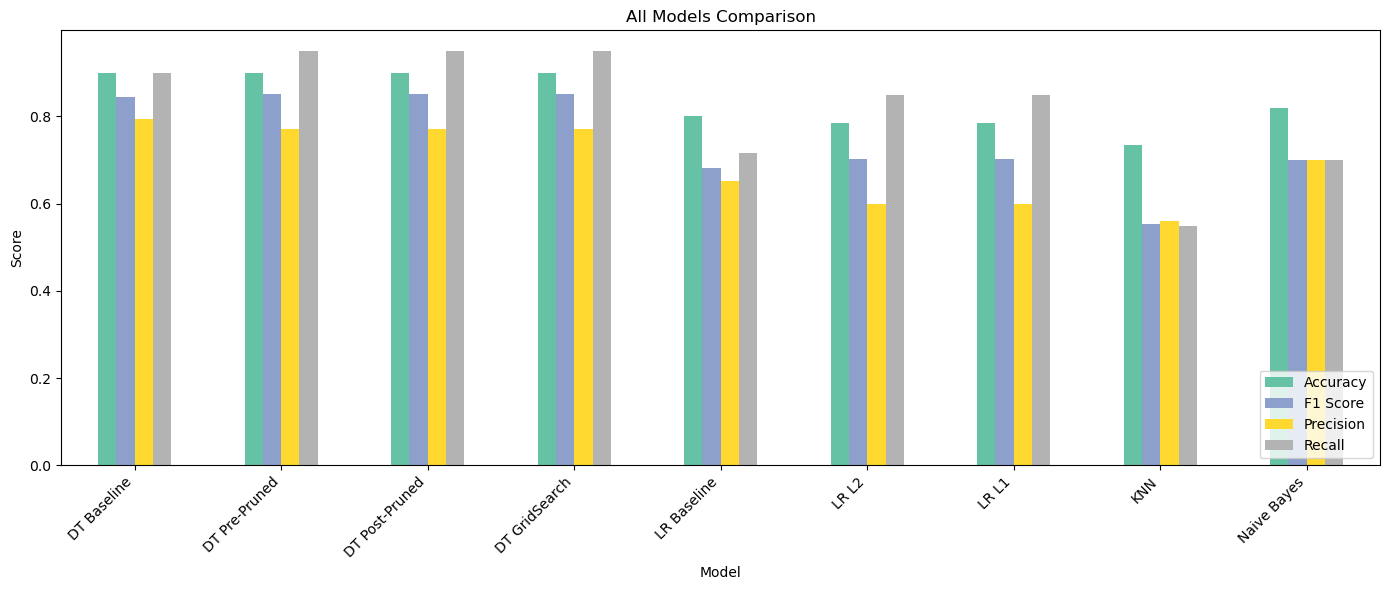

In [27]:
#ALL MODELS COMPARISON
results = pd.DataFrame({
    'Model': [
        'DT Baseline', 'DT Pre-Pruned', 'DT Post-Pruned',
        'DT GridSearch', 'LR Baseline', 'LR L2', 'LR L1',
        'KNN', 'Naive Bayes'
    ],
    'Accuracy': [
        accuracy_score(y_test, y_pred_baseline),
        accuracy_score(y_test, y_pred_pre),
        accuracy_score(y_test, y_pred_post),
        accuracy_score(y_test, y_pred_best_dt),
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_lr_l2),
        accuracy_score(y_test, y_pred_lr_l1),
        accuracy_score(y_test, y_pred_knn),
        accuracy_score(y_test, y_pred_nb)
    ],
    'F1 Score': [
        f1_score(y_test, y_pred_baseline),
        f1_score(y_test, y_pred_pre),
        f1_score(y_test, y_pred_post),
        f1_score(y_test, y_pred_best_dt),
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_lr_l2),
        f1_score(y_test, y_pred_lr_l1),
        f1_score(y_test, y_pred_knn),
        f1_score(y_test, y_pred_nb)
    ],
    'Precision': [
        precision_score(y_test, y_pred_baseline),
        precision_score(y_test, y_pred_pre),
        precision_score(y_test, y_pred_post),
        precision_score(y_test, y_pred_best_dt),
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_lr_l2),
        precision_score(y_test, y_pred_lr_l1),
        precision_score(y_test, y_pred_knn),
        precision_score(y_test, y_pred_nb)
    ],
    'Recall': [
        recall_score(y_test, y_pred_baseline),
        recall_score(y_test, y_pred_pre),
        recall_score(y_test, y_pred_post),
        recall_score(y_test, y_pred_best_dt),
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_lr_l2),
        recall_score(y_test, y_pred_lr_l1),
        recall_score(y_test, y_pred_knn),
        recall_score(y_test, y_pred_nb)
    ]
}).round(4)

print(results.to_string(index=False))

# Bar chart
results.set_index('Model')[['Accuracy', 'F1 Score', 'Precision', 'Recall']].plot(
    kind='bar', figsize=(14, 6), colormap='Set2'
)
plt.title("All Models Comparison")
plt.ylabel("Score")
plt.xticks(rotation=45, ha='right')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

## Conclusion & Business Recommendation

### Model Performance Comparison

| Model | Accuracy | F1 Score | Precision | Recall |
| :--- | :---: | :---: | :---: | :---: |
| **Decision Tree (Baseline)** | 0.900 | 0.8438 | 0.7941 | 0.9000 |
| **Decision Tree (Pre-Pruned)** | 0.900 | 0.8507 | 0.7703 | 0.9500 |
| **Decision Tree (Post-Pruned)**| 0.900 | 0.8507 | 0.7703 | 0.9500 |
| **Decision Tree (GridSearch)** | **0.900** | **0.8507** | **0.7703** | **0.9500** |
| **Logistic Regression (Baseline)**| 0.800 | 0.6825 | 0.6515 | 0.7167 |
| **Logistic Regression (L2)** | 0.785 | 0.7034 | 0.6000 | 0.8500 |
| **Logistic Regression (L1)** | 0.785 | 0.7034 | 0.6000 | 0.8500 |
| **KNN** | 0.735 | 0.5546 | 0.5593 | 0.5500 |
| **Naive Bayes** | 0.820 | 0.7000 | 0.7000 | 0.7000 |

### Problem Context
SecureTrust Bank needs to predict loan approvals automatically. Two costly mistakes exist in their manual process:
1. **Approving bad customers** → Leads to financial loss.
2. **Rejecting good customers** → Leads to business loss.

Therefore, the **F1 Score** is used as the primary metric because it effectively balances both Precision and Recall.

### The Winning Model
**Best Model:** Decision Tree (Tuned via GridSearch)

### Why not just use Accuracy?
The dataset is imbalanced—65% of loans are rejected, and 35% are approved. A "dumb" model that predicts "Rejected" every single time will always get 65% accuracy, but it catches zero approved customers. The F1 Score cannot be fooled by this imbalance.

### Most Important Feature: Credit_Score
Customers with higher credit scores are significantly more likely to get loans approved. This matches real-world financial logic perfectly!

### Business Recommendation
The bank should focus on **Credit_Score**, **DTI_Ratio**, and **Savings** as primary screening criteria. The model proves that these features drive the vast majority of loan decisions.